# 05 · Electric machines: losses, ratings and four ways to weigh a motor

`powertrain/components/motor.py` (252 lines) and `generator.py` (46 lines) hold the electric machines. A motor and a
generator are the same machine in two quadrants; they share the loss and mass submodels. This notebook takes them
apart: the operating equations, the McDonald loss model and its efficiency map, how ratings follow from the
peak-efficiency point ("rubber" machines), the four mass models, the public machine database behind one of them,
and finally a small sizing problem that shows the speed/gear-ratio trade the Halo makes.

**In this notebook**
1. `Motor.evaluate` and `Generator.evaluate`: power flow and sign conventions.
2. Loss models: the quadratic `SimpleMotorLossModel` and McDonald's parametric model (AIAA 2015-1676).
3. `rubber_machine`: ratings from the peak-efficiency point.
4. Mass models: power / specific power, torque density with a power cap, the database fit, whole units.
5. The database: `data/machines/aerospace_motors.csv` and `fit_torque_density`.
6. Sizing a motor and its gear ratio in one Opti.
7. How the Halo builds its machines.

**Run time:** a few seconds.

In [1]:
from tutorial_helpers import *
import numpy as onp
import inspect
from dataclasses import replace
from aircraft_closure.powertrain.components.motor import (Motor, SimpleMotorLossModel, McDonaldMotorLossModel,
                                                          TorqueDensityMassModel, DatabaseMassModel,
                                                          UnitMachineMassModel, rubber_machine)
from aircraft_closure.powertrain.components.generator import Generator

## 1. Operating equations and signs

The interface is `evaluate(speed_rad_s, torque_Nm, voltage_V)` for both machines; voltage is accepted so that later loss
maps could depend on it (none do yet). With $P_L(\omega, Q)$ the loss:

| | Shaft power | Electrical power | Current |
|---|---|---|---|
| `Motor` (motoring quadrant) | $\omega Q$ (out) | $\omega Q + P_L$ (in) | $P_e / V$, positive drawn from the bus |
| `Generator` (generating quadrant) | $\omega Q$ (in) | $\omega Q - P_L$ (out) | $P_e / V$, positive delivered to the bus |

Both treat speed and torque as non-negative. A generator asked for less shaft power than its losses would report negative
electrical output: the caller must prevent that (the flight point bounds generator torque below by zero, and the power balance
then sets it).

In [2]:
motor, generator = Motor(), Generator()
for name, machine in (("motor", motor), ("generator", generator)):
    r = machine.evaluate(400.0, 200.0, 800.0)
    print(f"{name:<10} shaft {r.power_shaft_W / 1e3:6.2f} kW  electrical {r.power_electric_W / 1e3:6.2f} kW  "
          f"loss {r.power_loss_W / 1e3:5.2f} kW  current {r.current_A:6.1f} A")
check("same loss in both quadrants at the same point",
      abs(motor.evaluate(400, 200, 800).power_loss_W - generator.evaluate(400, 200, 800).power_loss_W) < 1e-9)

motor      shaft  80.00 kW  electrical  83.33 kW  loss  3.33 kW  current  104.2 A
generator  shaft  80.00 kW  electrical  76.67 kW  loss  3.33 kW  current   95.8 A
PASS  same loss in both quadrants at the same point


## 2. Loss models

### The simplest: quadratic in torque and speed

`SimpleMotorLossModel`: $P_L = k_Q Q^2 + k_\omega \omega^2$, copper loss plus a speed-dependent iron/windage term with two
coefficients that need calibration. It is kept as the simplest model (rule 10) and is not used by the Halo.

### McDonald's parametric model

McDonald (AIAA 2015-1676) writes the loss as

$$P_L = C_0 + C_1\,\omega + C_2\,\omega^3 + C_3\,Q^2$$

(constant, friction-like, windage-like and copper terms), and fixes the four coefficients from four quantities a
designer actually knows: the speed $\hat\omega$ and torque $\hat Q$ of peak efficiency, the peak efficiency $\hat\eta$,
and the **parasite loss ratio** $k_0 \in [0, 1]$, the share of no-load (speed-only) losses at the peak:

In [3]:
print(inspect.getsource(McDonaldMotorLossModel.coefficients))

    def coefficients(self):
        speed_rad_s = self.speed_peak_efficiency_rad_s
        torque_Nm = self.torque_peak_efficiency_Nm
        loss_ratio = (1 - self.efficiency_peak) / self.efficiency_peak
        constant_W = self.parasite_loss_ratio * speed_rad_s * torque_Nm * loss_ratio / 6
        return McDonaldLossCoefficients(
            constant_W=constant_W,
            linear_W_s_rad=-3 * constant_W / (2 * speed_rad_s) + torque_Nm * loss_ratio / 4,
            cubic_W_s3_rad3=constant_W / (2 * speed_rad_s**3) + torque_Nm * loss_ratio / (4 * speed_rad_s**2),
            torque_W_Nm2=speed_rad_s * loss_ratio / (2 * torque_Nm),
        )



The construction guarantees that the efficiency map has its maximum exactly at $(\hat\omega, \hat Q)$ with value $\hat\eta$.
Check that numerically: efficiency there, and a zero gradient of efficiency with respect to speed and torque:

In [4]:
losses = McDonaldMotorLossModel(speed_peak_efficiency_rad_s=400.0, torque_peak_efficiency_Nm=200.0,
                                efficiency_peak=0.96, parasite_loss_ratio=0.5)

def efficiency_motor(speed_rad_s, torque_Nm, model=losses):
    shaft_W = speed_rad_s * torque_Nm
    return shaft_W / (shaft_W + model.evaluate(speed_rad_s, torque_Nm, 800.0))

h = 1e-4
d_speed = (efficiency_motor(400 + h, 200) - efficiency_motor(400 - h, 200)) / (2 * h)
d_torque = (efficiency_motor(400, 200 + h) - efficiency_motor(400, 200 - h)) / (2 * h)
print(f"efficiency at the peak point {efficiency_motor(400.0, 200.0):.6f}; gradient ({d_speed:.1e}, {d_torque:.1e})")
check("McDonald: efficiency is exactly eta_hat at (w_hat, Q_hat)", abs(efficiency_motor(400.0, 200.0) - 0.96) < 1e-12)
check("McDonald: (w_hat, Q_hat) is a stationary point of efficiency", abs(d_speed) < 1e-7 and abs(d_torque) < 1e-7)
c = losses.coefficients()
check("all four coefficients are non-negative for k0 in [0, 1]",
      min(c.constant_W, c.linear_W_s_rad, c.cubic_W_s3_rad3, c.torque_W_Nm2) >= 0)

efficiency at the peak point 0.960000; gradient (5.6e-13, 0.0e+00)
PASS  McDonald: efficiency is exactly eta_hat at (w_hat, Q_hat)
PASS  McDonald: (w_hat, Q_hat) is a stationary point of efficiency
PASS  all four coefficients are non-negative for k0 in [0, 1]


The efficiency map, and what the parasite ratio $k_0$ does to it (low $k_0$: losses mostly copper, a broad island at high
speed; high $k_0$: losses mostly no-load, efficiency collapses at light load):

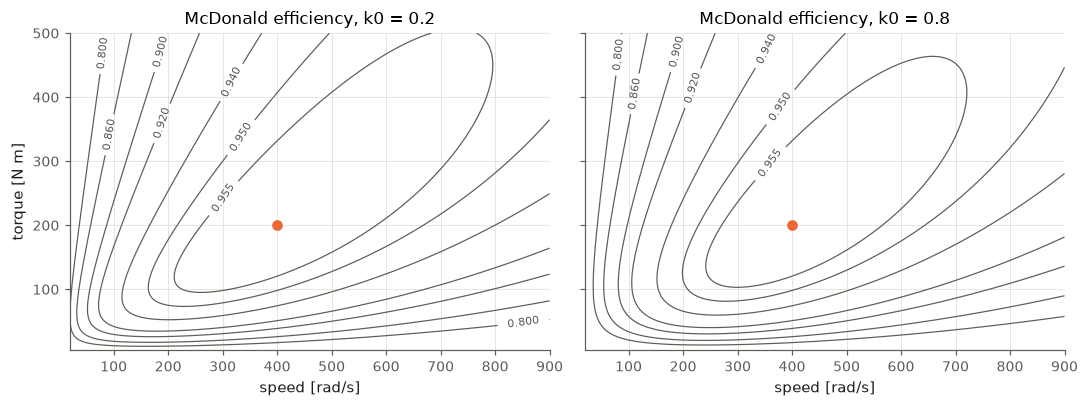

In [5]:
speeds = onp.linspace(20, 900, 220)
torques = onp.linspace(5, 500, 220)
W, Q = onp.meshgrid(speeds, torques)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, k0 in zip(axes, (0.2, 0.8)):
    model = replace(losses, parasite_loss_ratio=k0)
    eta = efficiency_motor(W, Q, model)
    cs = ax.contour(W, Q, eta, levels=[0.80, 0.86, 0.90, 0.92, 0.94, 0.95, 0.955], colors=ink_muted, linewidths=0.8)
    ax.clabel(cs, fmt="%.3f", fontsize=7)
    ax.plot(400, 200, "o", color=orange)
    ax.set(xlabel="speed [rad/s]", title=f"McDonald efficiency, k0 = {k0}")
axes[0].set_ylabel("torque [N m]")
plt.tight_layout(); plt.show()

In the sizing, $\hat\omega$ and $\hat Q$ are **design variables** (the loss coefficients are then expressions of them), so the
optimizer places the efficiency island where the machine actually works. Generator speed is fixed to the generator's
$\hat\omega$ in every flight point (`flight_point.py`: `speed_generator_rad_s = generator_model.loss_model.speed_peak_efficiency_rad_s`),
so the generator always runs at its best speed; its torque varies with the power demanded.

## 3. Rubber machines: ratings from the peak point

McDonald's eq. 4 ties the ratings to the peak point with three ratios: $Q_\text{max} = k_Q \hat Q$,
$P_\text{rated} = k_P\,\hat\omega \hat Q$, $\omega_\text{max} = k_\omega \hat\omega$. `rubber_machine(Motor, w_hat, Q_hat, ...)`
returns a `Motor` (or `Generator`) built that way. The Halo uses $k_Q = 2.5$, $k_P = 1.25$, $k_\omega = 2.5$:

In [6]:
m = rubber_machine(Motor, 200.0, 600.0, torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5)
print(f"peak point 200 rad/s, 600 N m ->  max torque {m.max_torque_Nm:.0f} N m, rated power {m.power_rated_W / 1e3:.0f} kW, "
      f"max speed {m.max_speed_rad_s:.0f} rad/s")
opti = asb.Opti()
q_hat = opti.variable(init_guess=600.0, scale=100.0)
sized = rubber_machine(Motor, 200.0, q_hat, torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5,
                       mass_model=TorqueDensityMassModel())
print("with a variable Q_hat, every rating, the loss model and the mass are expressions:",
      type(sized.power_rated_W).__name__, type(sized.loss_model.coefficients().constant_W).__name__,
      type(sized.get_mass()).__name__)

peak point 200 rad/s, 600 N m ->  max torque 1500 N m, rated power 150 kW, max speed 500 rad/s


with a variable Q_hat, every rating, the loss model and the mass are expressions: MX MX MX


## 4. Four mass models

| `mass_model` | Mass | When |
|---|---|---|
| `None` | $P_\text{rated} / (P/m)$, 5 kW/kg motor, 4 kW/kg generator | simplest; early tiers |
| `TorqueDensityMassModel` | softmax$(Q_\text{max}/\tau,\ P_\text{rated}/(P/m)_\text{max})$ | electromagnetic mass scales with torque until a power-density cap |
| `DatabaseMassModel` | softmax$(Q_\text{cont}/\tau(\omega_\text{base}),\ P/(P/m)_\text{max})$, $\tau(\omega) = \tau_\text{ref}(\omega/\omega_\text{ref})^{-a}$ | torque density falling with base speed, fitted to public data |
| `UnitMachineMassModel` | $n \times m_\text{unit}$, $n$ whole units of a real product | "no rubber motors" (the Halo reference) |

Why torque? An electric machine's electromagnetic torque scales with rotor volume times shear stress, so its mass scales with
torque, not power. At fixed power a faster machine is lighter, until something else (mechanical stress, iron losses,
cooling) caps the power density. That is exactly what the torque-density model says:

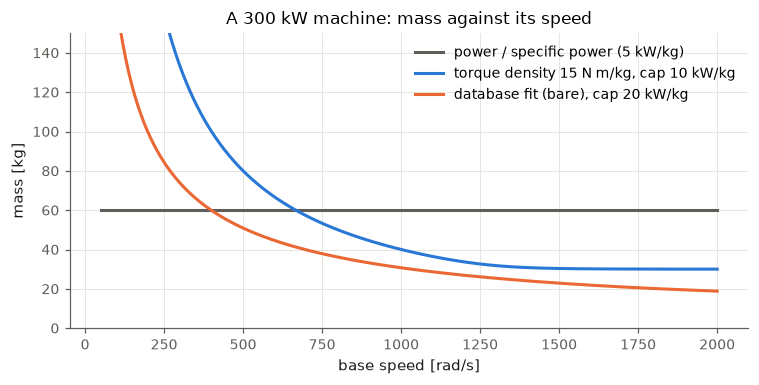

In [7]:
power_W = 300e3
speeds_rad_s = onp.linspace(50, 2000, 400)
fig, ax = plt.subplots(figsize=(7, 3.6))
for label, model, color in (("power / specific power (5 kW/kg)", None, ink_muted),
                            ("torque density 15 N m/kg, cap 10 kW/kg", TorqueDensityMassModel(), blue),
                            ("database fit (bare), cap 20 kW/kg", DatabaseMassModel(), orange)):
    masses = []
    for w in speeds_rad_s:
        # a machine rated 300 kW whose peak torque is 2 x the continuous torque at w
        machine = Motor(power_rated_W=power_W, max_torque_Nm=2 * power_W / w, mass_model=model)
        masses.append(machine.get_mass())
    ax.plot(speeds_rad_s, masses, color=color, lw=2, label=label)
ax.set(xlabel="base speed [rad/s]", ylabel="mass [kg]", ylim=(0, 150),
       title="A 300 kW machine: mass against its speed")
ax.legend(); plt.tight_layout(); plt.show()

The power-density model ignores speed entirely, so it cannot represent the central trade of a geared electric drive. The
torque models fall as $1/\omega$ (or $\omega^{a-1}$) and flatten on their caps; the softmax corner is smoothed by 2 kg.

### Whole units of a real product

`UnitMachineMassModel` builds a machine from $n$ stacked units of one product (here the Evolito D1500 used by the Halo motors:
40 kg, 1,500 N·m peak, 264 kW continuous, 2,500 rpm). With `count_units=None` it uses the **relaxed** count
$n = \text{softmax}(Q_\text{max}/Q_\text{unit},\ P/P_\text{unit})$, smooth so IPOPT can size it. With an integer it is fixed.
The Halo solves twice: relaxed, then rounds each count up and re-solves with the counts fixed (`solve_halo_sizing`, plan 035):

In [8]:
units = UnitMachineMassModel(mass_unit_kg=40.0, torque_peak_unit_Nm=1500.0, power_continuous_unit_W=1400.0 * 1800 * u.rpm,
                             speed_max_unit_rad_s=2500 * u.rpm)
needed = Motor(power_rated_W=500e3, max_torque_Nm=2800.0)
relaxed = units.count_units_relaxed(needed)
print(f"a 2,800 N m / 500 kW lane needs {relaxed:.3f} units (relaxed) -> {int(onp.ceil(relaxed - 1e-3))} whole units, "
      f"{replace(units, count_units=int(onp.ceil(relaxed - 1e-3))).mass_kg(needed):.0f} kg")
check("the relaxed count is at least the larger of the torque and power ratios",
      relaxed >= max(2800 / 1500, 500e3 / units.power_continuous_unit_W))

a 2,800 N m / 500 kW lane needs 1.917 units (relaxed) -> 2 whole units, 80 kg
PASS  the relaxed count is at least the larger of the torque and power ratios


## 5. The machine database and the fit behind `DatabaseMassModel`

`data/machines/aerospace_motors.csv` holds published aerospace machines, each row cited by URL. `machine_database.py` loads it
(SI conversion at load) and fits $\ln\tau = \ln\tau_\text{ref} - a\ln(\omega_\text{base}/\omega_\text{ref})$ by least squares
over rows marked `fit` (bare machines with published continuous torque and power). The fitted constants are the defaults of
`DatabaseMassModel`, and the test suite checks they agree:

21 machines, 15 used in the fit
tau_ref = 11.79 N m/kg at 500 rad/s, exponent 0.271, RMS log residual 0.37 (a factor 1.45)
PASS  the fit reproduces DatabaseMassModel's defaults


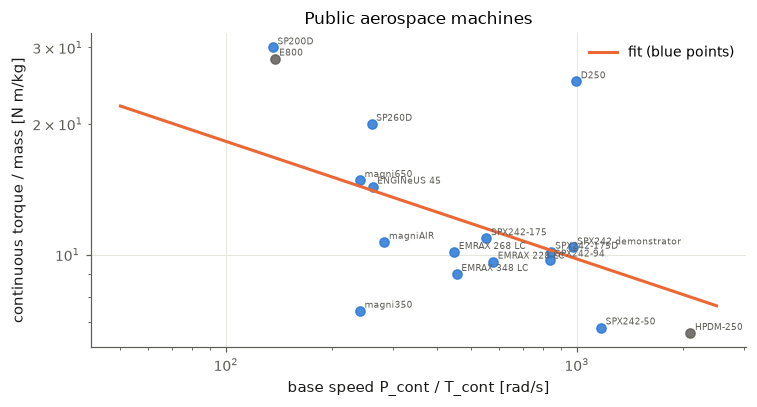

In [9]:
from aircraft_closure.powertrain.machine_database import load_machine_database, fit_torque_density
records = load_machine_database()
fit = fit_torque_density(records)
print(f"{len(records)} machines, {sum(r.fit for r in records)} used in the fit")
print(f"tau_ref = {fit.torque_density_ref_Nm_kg:.2f} N m/kg at {fit.speed_ref_rad_s:.0f} rad/s, exponent {fit.exponent_speed:.3f}, "
      f"RMS log residual {fit.rms_log_residual:.2f} (a factor {onp.exp(fit.rms_log_residual):.2f})")
check("the fit reproduces DatabaseMassModel's defaults",
      abs(fit.torque_density_ref_Nm_kg - DatabaseMassModel().torque_density_ref_Nm_kg) < 0.01
      and abs(fit.exponent_speed - DatabaseMassModel().exponent_speed) < 0.001)

fig, ax = plt.subplots(figsize=(7, 3.8))
for r in records:
    density = r.torque_density_continuous_Nm_kg()
    speed = r.speed_base_rad_s()
    if density is None or speed is None:
        continue
    ax.plot(speed, density, "o", color=blue if r.fit else ink_muted, ms=6, alpha=0.85)
    ax.annotate(r.name, (speed, density), fontsize=6, xytext=(3, 2), textcoords="offset points", color=ink_muted)
w = onp.linspace(50, 2500, 200)
ax.plot(w, fit.torque_density_Nm_kg(w), color=orange, lw=2, label="fit (blue points)")
ax.set(xscale="log", yscale="log", xlabel="base speed P_cont / T_cont [rad/s]", ylabel="continuous torque / mass [N m/kg]",
       title="Public aerospace machines")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Sizing a motor and its gear ratio

A rotor needs 400 kW at 60 rad/s. Between the motor and the rotor is a gearbox of ratio $r$: the motor turns at $60 r$ and
supplies torque $P/(60 r \eta)$. A faster motor is lighter, but more ratio means more stages (heavier, less efficient). Choose
$r$ and the motor's peak point to minimize motor + gearbox mass plus a loss penalty (a stand-in for fuel). The gearbox mass
law here is a toy ($m = 0.04\,Q_\text{out}^{0.8} \times$ stage factor); the Halo uses the AFDD drive-system equations
(tutorial 06).

ratio 23.07 (1.95 stages), motor at 1384 rad/s (13220 rpm), 298 N m
motor peak point 1373 rad/s, 240 N m; motor 42.1 kg, gearbox 58.9 kg, loss 29.6 kW


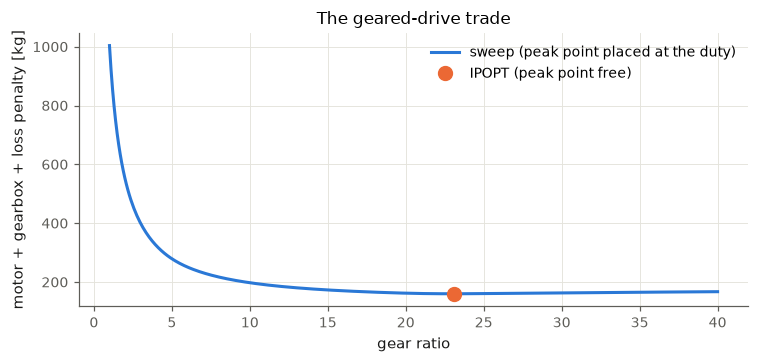

PASS  IPOPT is no worse than the sweep


In [10]:
from aircraft_closure.powertrain.components.gearbox import GearStageModel
stages = GearStageModel(staircase=False)
power_rotor_W, speed_rotor_rad_s, penalty_kg_per_kW = 400e3, 60.0, 2.0

def drive(ratio, speed_peak_rad_s, torque_peak_Nm):
    efficiency_gear = stages.efficiency(ratio)
    speed_motor_rad_s = ratio * speed_rotor_rad_s
    torque_motor_Nm = power_rotor_W / (efficiency_gear * speed_motor_rad_s)
    motor = rubber_machine(Motor, speed_peak_rad_s, torque_peak_Nm, torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5,
                           mass_model=TorqueDensityMassModel())
    state = motor.evaluate(speed_motor_rad_s, torque_motor_Nm, 800.0)
    torque_out_Nm = power_rotor_W / speed_rotor_rad_s
    mass_gearbox_kg = 0.04 * torque_out_Nm**0.8 * stages.mass_factor(ratio)
    loss_kW = (state.power_loss_W + power_rotor_W * (1 / efficiency_gear - 1)) / 1e3
    return dict(motor=motor, state=state, speed_motor_rad_s=speed_motor_rad_s, torque_motor_Nm=torque_motor_Nm,
                mass_motor_kg=motor.get_mass(), mass_gearbox_kg=mass_gearbox_kg, loss_kW=loss_kW,
                stages=stages.count_stages(ratio))

opti = asb.Opti()
ratio = opti.variable(init_guess=5.0, lower_bound=1.0, upper_bound=60.0)
speed_peak_rad_s = opti.variable(init_guess=300.0, scale=100.0, lower_bound=20.0)
torque_peak_Nm = opti.variable(init_guess=800.0, scale=100.0, lower_bound=10.0)
d = drive(ratio, speed_peak_rad_s, torque_peak_Nm)
limits = d["motor"].get_limits()
opti.subject_to([d["torque_motor_Nm"] / limits.max_torque_Nm <= 1,
                 d["speed_motor_rad_s"] / limits.max_speed_rad_s <= 1,
                 d["state"].power_shaft_W / limits.power_rated_W <= 1])
opti.minimize((d["mass_motor_kg"] + d["mass_gearbox_kg"] + penalty_kg_per_kW * d["loss_kW"]) / 100)
s = opti.solve(verbose=False)
print(f"ratio {s.value(ratio):.2f} ({s.value(d['stages']):.2f} stages), motor at {s.value(d['speed_motor_rad_s']):.0f} rad/s "
      f"({s.value(d['speed_motor_rad_s']) / u.rpm:.0f} rpm), {s.value(d['torque_motor_Nm']):.0f} N m")
print(f"motor peak point {s.value(speed_peak_rad_s):.0f} rad/s, {s.value(torque_peak_Nm):.0f} N m; "
      f"motor {s.value(d['mass_motor_kg']):.1f} kg, gearbox {s.value(d['mass_gearbox_kg']):.1f} kg, loss {s.value(d['loss_kW']):.1f} kW")

# The same trade by brute force over the ratio (peak point at the operating point, the best place for it).
ratios = onp.linspace(1.0, 40.0, 400)
totals = []
for r_ in ratios:
    e = drive(r_, r_ * speed_rotor_rad_s, power_rotor_W / (stages.efficiency(r_) * r_ * speed_rotor_rad_s) / 1.0)
    # rating needs: torque <= 2.5 Q_hat holds with margin here; keep power <= 1.25 w Q_hat -> scale Q_hat
    q_needed = max(e["torque_motor_Nm"] / 2.5, e["state"].power_shaft_W / (1.25 * r_ * speed_rotor_rad_s))
    e = drive(r_, r_ * speed_rotor_rad_s, q_needed)
    totals.append(e["mass_motor_kg"] + e["mass_gearbox_kg"] + penalty_kg_per_kW * e["loss_kW"])
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ratios, totals, color=blue, lw=2, label="sweep (peak point placed at the duty)")
ax.plot(s.value(ratio), s.value(d["mass_motor_kg"] + d["mass_gearbox_kg"] + penalty_kg_per_kW * d["loss_kW"]), "o",
        color=orange, ms=9, label="IPOPT (peak point free)")
ax.set(xlabel="gear ratio", ylabel="motor + gearbox + loss penalty [kg]", title="The geared-drive trade")
ax.legend(); plt.tight_layout(); plt.show()
check("IPOPT is no worse than the sweep", s.value(d["mass_motor_kg"] + d["mass_gearbox_kg"] + penalty_kg_per_kW * d["loss_kW"])
      <= min(totals) + 0.5)

Read the result in terms of the model: the motor gets lighter as $1/\omega$ until the 10 kW/kg cap, after which more ratio
only adds gearbox mass and losses. In the Halo the rotor gearbox also sees the AFDD weight equations and the motor is built
from whole units with a 2,500 rpm limit, so the optimum there is a single ~4.5:1 stage (README, "Drive").

## 7. How the Halo builds its machines

`build_halo_aircraft` (in `examples/halo_sizing.py`) makes each lane motor and each generator in three steps, all visible
in the source below:

1. `rubber_machine(Motor, w_hat, Q_hat, torque_ratio=2.5, power_ratio=1.25, speed_ratio=2.5, mass_model=..., thermal_model=...)`,
   with `w_hat` and `Q_hat` design variables (`HaloDesign.speed_peak_motor_rad_s`, `torque_peak_motor_Nm`);
2. with `machine_mass_model="units"`, `unit_machine(...)` replaces its limits and mass with $n$ units' (the rubber
   machine keeps placing the efficiency map);
3. with the thermal model on, the rated power becomes a *continuous* rating, and the flight points limit winding temperature
   instead of power (tutorial 09).

In [11]:
import examples.halo_sizing as hs
source = inspect.getsource(hs.build_halo_aircraft)
start = source.find("    motor = rubber_machine")
print(source[start:start + 1950])

    motor = rubber_machine(Motor, speed_peak_motor_rad_s, d.torque_peak_motor_Nm, **ratios, mass_model=mass_model,
                           **thermal)
    generator = rubber_machine(Generator, speed_peak_generator_rad_s, d.torque_peak_generator_Nm, **ratios,
                               mass_model=mass_model_generator, **thermal)
    if a.machine_mass_model == "units":
        # Plan 035: whole units of real machines. The machine's limits are n x the unit's published ratings (max
        # torque, continuous power) and the unit's max speed; the peak-efficiency point (w_hat, Q_hat, design
        # variables) only places the efficiency map. n: `count_units_*`, or the relaxed count the rubber ratings
        # would need (used only to find n). The inverter is added unless it is a Tier 15 component.
        inverter = None if a.electrical_layer else a.specific_power_inverter_W_kg
        motor = unit_machine(motor, a.count_units_motor, UnitMachineMassModel(
            a.mass_unit_mot

## Limits and next steps

**Why it is built this way:** McDonald losses give a realistic efficiency island from four interpretable numbers, scale with symbolic ratings and stay a smooth
polynomial. Torque sizing is the physics and makes rotor speed, gear ratio and direct drive real trades (direct drive was checked: about 31 kN m per motor,
about 2 t of motors, infeasible). Whole units replaced optimistic rubber scaling and flipped the drive from fast motors with about 36:1 gearing to slow
axial-flux motors behind one 4.5:1 stage (plan 035).

**What it can't do**

- **The McDonald map is a parametric shape**, not a manufacturer map; with units, the peak point places the map wherever the optimizer likes, not where the
  real product's map is. No voltage dependence (field weakening), no temperature dependence of losses.
- **Unit data are partly assumed**: the D1500 has no published continuous rating (its 285 kW is a 30 s rating); the 1,400 N m continuous figure is an
  assumption (35 N m/kg). One catalogue product per role.
- **Rounding up is not an integer optimum**: a different count with a re-optimized design could be lighter; it has not been enumerated.
- **No torque-speed envelope**: maximum torque, maximum speed and rated power are independent bounds.

**What's next:** supplier data sheets (efficiency maps, continuous and peak ratings, thermal limits) into the same interfaces (README propulsion work
package); enumeration of unit catalogues and mixed unit counts (`docs/NEXT_STEPS.md`).

## Summary

- One machine, two quadrants: motor electrical = shaft + loss; generator electrical = shaft − loss.
- McDonald's loss model is set by the peak-efficiency point, peak efficiency and parasite ratio; the map peaks exactly there.
- Rubber machines derive ratings from the peak point; in sizing the peak point is a design variable.
- Mass by torque (with a power cap) captures the speed trade; the database model fits it to public machines; the unit model
  builds machines from whole real products with a relaxed-then-integer solve.

## Check yourself

<details><summary>1. Why does the flight point run the generator at its peak-efficiency speed, and what would change if it did not?</summary>

The turbogenerator's speed is set by its step-up gearbox from a fixed engine output speed, so in steady operation it has a design speed; choosing that design speed to be the peak-efficiency speed is optimal and removes a per-point variable. Making it free per point would add a variable and, with a fixed gear ratio, an equality tying it to engine speed.
</details>

<details><summary>2. With the power-density mass model, what gear ratio would the optimizer choose in section 6, and why?</summary>

The lowest that satisfies the speed limits (likely 1): motor mass would not depend on speed, so any ratio only adds gearbox mass and losses. That is why the torque-based models were introduced (plan 018).
</details>

<details><summary>3. The relaxed unit count is 2.03. What does the Halo driver do?</summary>

Rounds up (with a small 1e-3 tolerance) to 3 units and re-solves the whole problem with the count fixed, so every other part re-optimizes around the heavier, stronger motor.
</details>

In [12]:
check_summary()

7 of 7 checks passed
